# Neural Network Calibration Research: Bank Marketing Dataset

**Research Question:** How well-calibrated are supervised neural networks on bank marketing prediction?

---

## 1. Introduction & Problem Statement

### Dataset: Bank Marketing

- **Task:** Binary classification - predict term deposit subscription (Yes vs No)
- **Size:** ~41,000 marketing campaign contacts
- **Features:** 20 features (client data, campaign info, economic indicators)
- **Source:** UCI Machine Learning Repository

### Research Objectives

1. Establish supervised baseline on marketing domain
2. Measure calibration quality  
3. Apply temperature scaling
4. Compare with other domains (Adult Income, Wine Quality)

## 2. Setup and Imports

In [31]:
!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn -q


[notice] A new release of pip is available: 24.0 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, brier_score_loss
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
sns.set_style('whitegrid')

## 3. Data Loading

In [33]:
def load_bank_marketing_dataset():
    #url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional-full.csv"
    
    try:
        df = pd.read_csv('C:/Users/revku/Documents/Research paper/Datasets/bank+marketing/bank/bank-full.csv',sep=";")
        print(f"Dataset loaded from URL successfully!")
    except:
        # Alternative: load from local file if downloaded
        print("Direct URL failed. Please download manually from:")
        print("https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip")
        print("\nThen load with: df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')")
        return None
    
    print(f"Total samples: {len(df)}")
    return df

df = load_bank_marketing_dataset()
if df is not None:
    df.head()
df.head(10)

Dataset loaded from URL successfully!
Total samples: 45211


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


## 4. Exploratory Data Analysis

Dataset Shape: (45211, 17)

Column Types:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

Target Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64


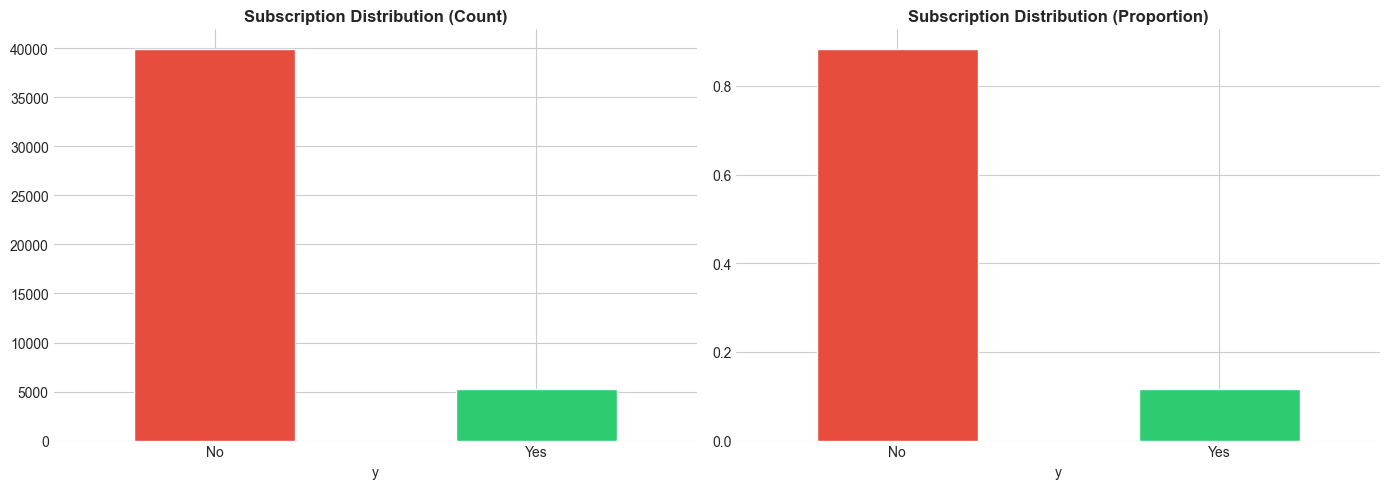

In [34]:
if df is not None:
    print("Dataset Shape:", df.shape)
    print("\nColumn Types:")
    print(df.dtypes)
    print("\nTarget Distribution:")
    print(df['y'].value_counts())
    
    # Visualize target distribution
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    df['y'].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'])
    ax[0].set_title('Subscription Distribution (Count)', fontweight='bold')
    ax[0].set_xticklabels(['No', 'Yes'], rotation=0)
    
    df['y'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['#e74c3c', '#2ecc71'])
    ax[1].set_title('Subscription Distribution (Proportion)', fontweight='bold')
    ax[1].set_xticklabels(['No', 'Yes'], rotation=0)
    
    plt.tight_layout()
    plt.show()

## 5. Data Preprocessing

In [35]:
def preprocess_bank_data(df):
    """
    Preprocess Bank Marketing dataset
    """
    df = df.copy()
    
    # Encode target variable
    df['y'] = (df['y'] == 'yes').astype(int)
    
    # Separate features and target
    X = df.drop('y', axis=1)
    y = df['y'].values
    
    # Identify categorical and numerical columns
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    print(f"Categorical columns: {len(categorical_cols)}")
    print(f"Numerical columns: {len(numerical_cols)}")
    
    # Encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    
    # Scale numerical features
    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    
    X = X.values.astype(np.float32)
    y = y.astype(np.int64)
    
    print(f"\nFeatures shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")
    
    return X, y, scaler, label_encoders

if df is not None:
    X, y, scaler, label_encoders = preprocess_bank_data(df)

Categorical columns: 9
Numerical columns: 7

Features shape: (45211, 16)
Class distribution: [39922  5289]


In [36]:
# Split data: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
)

print("Data Split:")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in splits:")
print(f"Train: {np.bincount(y_train)} -> {np.bincount(y_train)[1]/len(y_train)*100:.1f}% positive")
print(f"Val: {np.bincount(y_val)} -> {np.bincount(y_val)[1]/len(y_val)*100:.1f}% positive")
print(f"Test: {np.bincount(y_test)} -> {np.bincount(y_test)[1]/len(y_test)*100:.1f}% positive")

Data Split:
Train set: 27126 samples (60.0%)
Validation set: 9042 samples (20.0%)
Test set: 9043 samples (20.0%)

Class distribution in splits:
Train: [23953  3173] -> 11.7% positive
Val: [7984 1058] -> 11.7% positive
Test: [7985 1058] -> 11.7% positive


In [37]:
class TabularDataset(Dataset):
    """
    PyTorch Dataset for tabular data
    """
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Created DataLoaders with batch size: {batch_size}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Created DataLoaders with batch size: 128
Number of batches - Train: 212, Val: 71, Test: 71


Model Architecture:
MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total parameters: 10,562


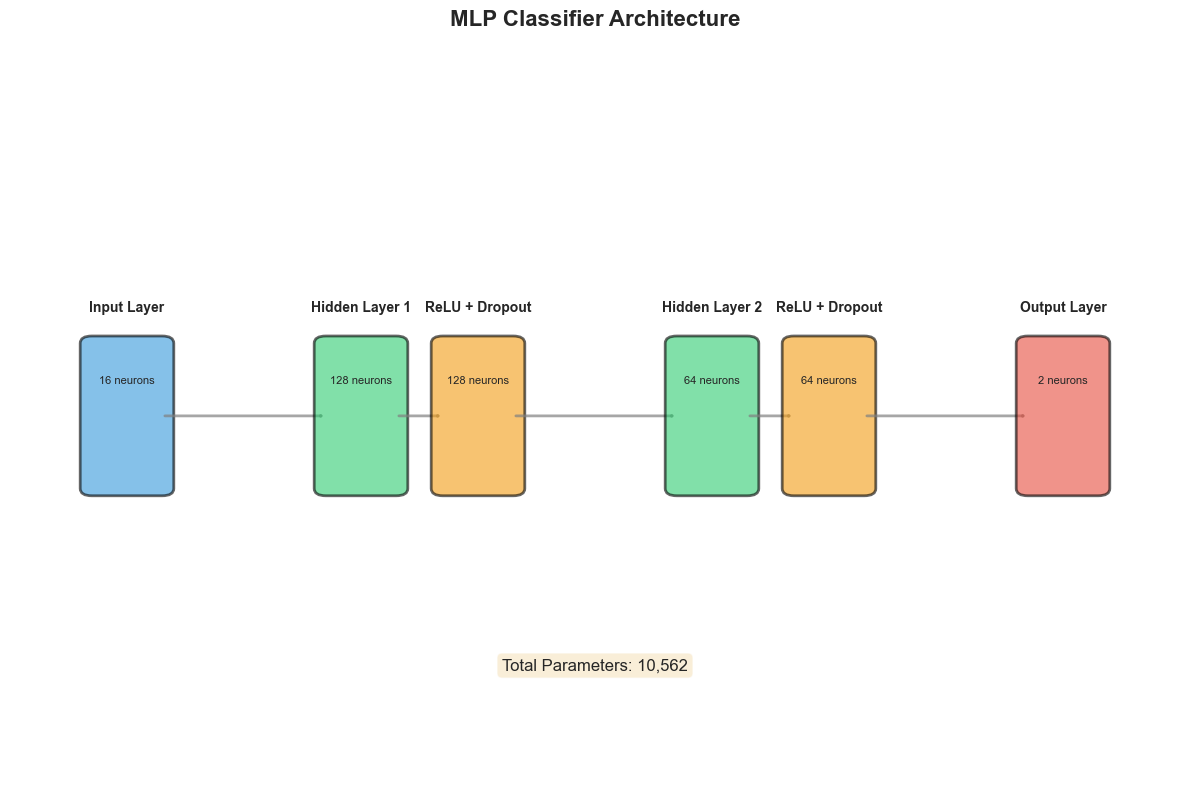

In [38]:
class MLPClassifier(nn.Module):
    """
    Multi-Layer Perceptron for binary classification
    Architecture: Input → 128 → ReLU → Dropout → 64 → ReLU → Dropout → 2
    """
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.3):
        super(MLPClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim2, 2)  # 2 output classes
        )
    
    def forward(self, x):
        logits = self.network(x)
        return logits

# Initialize model
input_dim = X_train.shape[1]
model = MLPClassifier(input_dim).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def visualize_mlp_architecture(input_dim, hidden_dim1=128, hidden_dim2=64):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Define layer positions
    layers = [
        {'name': 'Input Layer', 'neurons': input_dim, 'x': 1, 'color': '#3498db'},
        {'name': 'Hidden Layer 1', 'neurons': hidden_dim1, 'x': 3, 'color': '#2ecc71'},
        {'name': 'ReLU + Dropout', 'neurons': hidden_dim1, 'x': 4, 'color': '#f39c12'},
        {'name': 'Hidden Layer 2', 'neurons': hidden_dim2, 'x': 6, 'color': '#2ecc71'},
        {'name': 'ReLU + Dropout', 'neurons': hidden_dim2, 'x': 7, 'color': '#f39c12'},
        {'name': 'Output Layer', 'neurons': 2, 'x': 9, 'color': '#e74c3c'}
    ]
    
    # Draw layers
    for i, layer in enumerate(layers):
        # Draw box
        box = FancyBboxPatch(
            (layer['x'] - 0.3, 4), 0.6, 2,
            boxstyle="round,pad=0.1",
            edgecolor='black',
            facecolor=layer['color'],
            alpha=0.6,
            linewidth=2
        )
        ax.add_patch(box)
        
        # Add text
        ax.text(layer['x'], 6.5, layer['name'], 
                ha='center', va='center', fontsize=10, fontweight='bold')
        ax.text(layer['x'], 5.5, f"{layer['neurons']} neurons", 
                ha='center', va='center', fontsize=8)
        
        # Draw arrows between layers
        if i < len(layers) - 1:
            arrow = FancyArrowPatch(
                (layer['x'] + 0.3, 5),
                (layers[i+1]['x'] - 0.3, 5),
                arrowstyle='->,head_width=0.4,head_length=0.4',
                color='gray',
                linewidth=2,
                alpha=0.7
            )
            ax.add_patch(arrow)
    
    # Add title
    plt.title('MLP Classifier Architecture', fontsize=16, fontweight='bold', pad=20)
    
    # Add legend
    total_params = sum(p.numel() for p in model.parameters())
    legend_text = f'Total Parameters: {total_params:,}'
    ax.text(5, 1.5, legend_text, ha='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('mlp_architecture_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize
visualize_mlp_architecture(input_dim)

In [39]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    """
    Train the neural network
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    print("Starting training...\n")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(logits.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = correct / total
        
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val Acc: {val_acc:.4f}")
    
    print("\nTraining complete!")
    return history

# Train the model
history = train_model(model, train_loader, val_loader, epochs=30, lr=0.001)

Starting training...

Epoch [5/30] - Train Loss: 0.2437, Val Loss: 0.2322, Val Acc: 0.8984
Epoch [10/30] - Train Loss: 0.2351, Val Loss: 0.2254, Val Acc: 0.8976
Epoch [15/30] - Train Loss: 0.2294, Val Loss: 0.2214, Val Acc: 0.9007
Epoch [20/30] - Train Loss: 0.2251, Val Loss: 0.2209, Val Acc: 0.9008
Epoch [25/30] - Train Loss: 0.2212, Val Loss: 0.2176, Val Acc: 0.8999
Epoch [30/30] - Train Loss: 0.2189, Val Loss: 0.2184, Val Acc: 0.8979

Training complete!


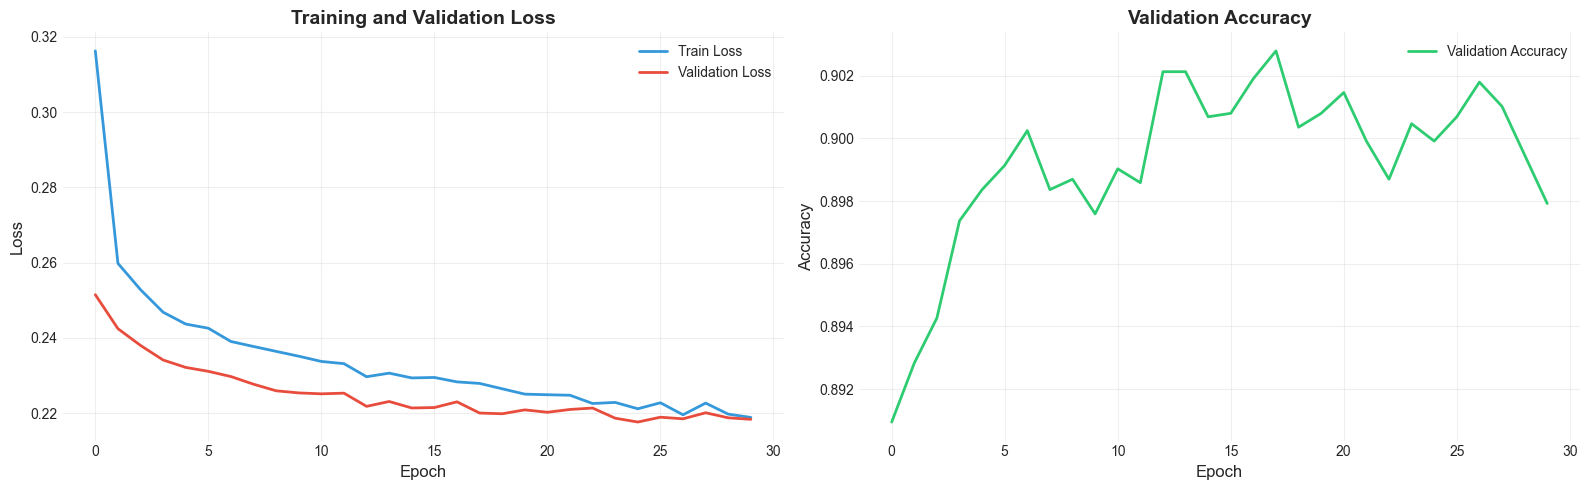

In [40]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2, color='#3498db')
ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#e74c3c')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#2ecc71')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

                    DETAILED PERFORMANCE REPORT

Metric                    Value          
----------------------------------------
Accuracy                  0.8991
Precision                 0.6106
Recall (Sensitivity)      0.3809
F1-Score                  0.4692
AUC-ROC                   0.9047
Average Precision         0.5571

Confusion Matrix:
----------------------------------------
True Negatives (TN):      7728
False Positives (FP):     257
False Negatives (FN):     655
True Positives (TP):      403

Additional Metrics:
----------------------------------------
Specificity               0.9678
False Positive Rate       0.0322
False Negative Rate       0.6191

Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K     0.9219    0.9678    0.9443      7985
        >50K     0.6106    0.3809    0.4692      1058

    accuracy                         0.8991      9043
   macro avg   

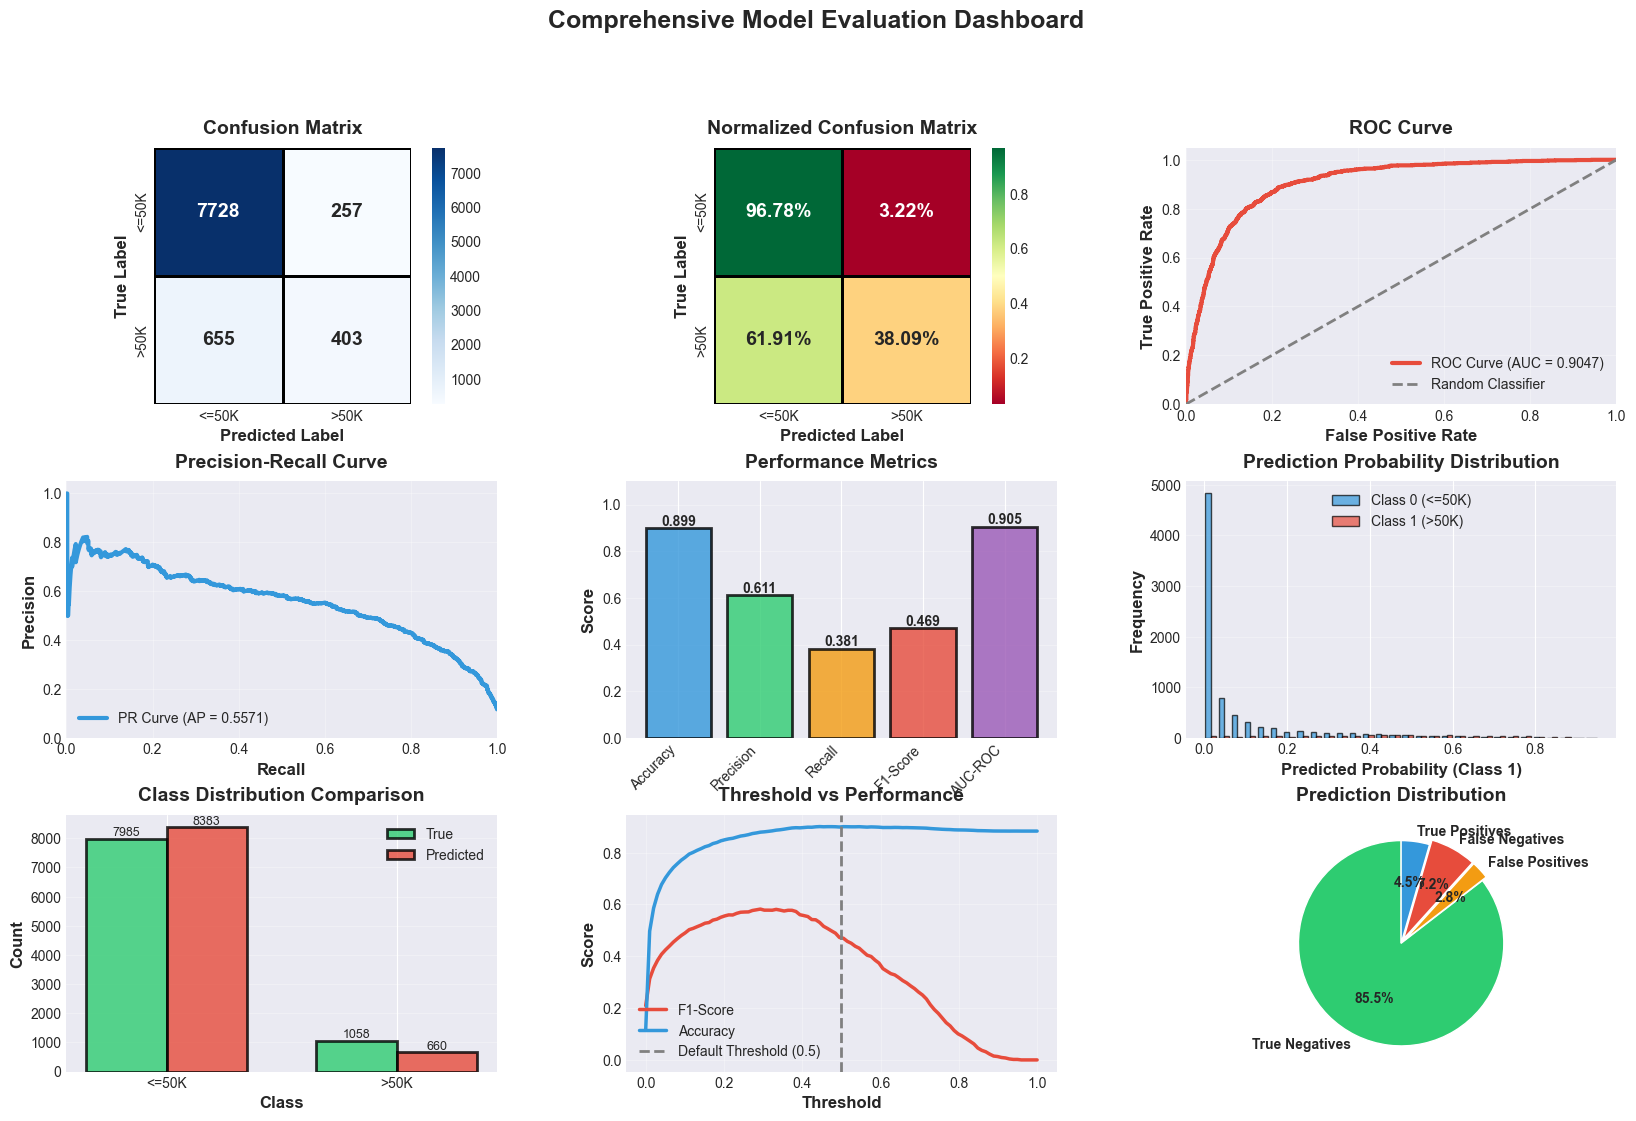

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score, precision_score, recall_score
)
import numpy as np

def evaluate_model(model, dataloader):
    """
    Evaluate model and return predictions, probabilities, and labels
    """
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    all_logits = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            _, predicted = torch.max(logits.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_logits.extend(logits.cpu().numpy())
    
    return (
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_labels),
        np.array(all_logits)
    )

def plot_comprehensive_evaluation(y_true, y_pred, y_prob, save_path='evaluation_results.png'):
    """
    Create comprehensive visualization of model performance
    """
    # Set style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob[:, 1])
    avg_precision = average_precision_score(y_true, y_prob[:, 1])
    cm = confusion_matrix(y_true, y_pred)
    
    # 1. Confusion Matrix (Enhanced)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax1)
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xticklabels(['<=50K', '>50K'])
    ax1.set_yticklabels(['<=50K', '>50K'])
    
    # 2. Normalized Confusion Matrix
    ax2 = fig.add_subplot(gs[0, 1])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', 
                cbar=True, square=True, linewidths=2, linecolor='black',
                annot_kws={'size': 14, 'weight': 'bold'}, ax=ax2)
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    ax2.set_xticklabels(['<=50K', '>50K'])
    ax2.set_yticklabels(['<=50K', '>50K'])
    
    # 3. ROC Curve
    ax3 = fig.add_subplot(gs[0, 2])
    fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])
    ax3.plot(fpr, tpr, color='#e74c3c', linewidth=3, 
             label=f'ROC Curve (AUC = {auc_roc:.4f})')
    ax3.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, 
             label='Random Classifier')
    ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax3.set_title('ROC Curve', fontsize=14, fontweight='bold', pad=10)
    ax3.legend(loc='lower right', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    
    # 4. Precision-Recall Curve
    ax4 = fig.add_subplot(gs[1, 0])
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob[:, 1])
    ax4.plot(recall_curve, precision_curve, color='#3498db', linewidth=3,
             label=f'PR Curve (AP = {avg_precision:.4f})')
    ax4.set_xlabel('Recall', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax4.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold', pad=10)
    ax4.legend(loc='lower left', fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    
    # 5. Metrics Bar Chart
    ax5 = fig.add_subplot(gs[1, 1])
    metrics_dict = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    }
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
    bars = ax5.bar(metrics_dict.keys(), metrics_dict.values(), color=colors, 
                   edgecolor='black', linewidth=2, alpha=0.8)
    ax5.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax5.set_title('Performance Metrics', fontsize=14, fontweight='bold', pad=10)
    ax5.set_ylim([0, 1.1])
    ax5.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
    plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 6. Prediction Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist([y_prob[y_true == 0, 1], y_prob[y_true == 1, 1]], 
             bins=30, label=['Class 0 (<=50K)', 'Class 1 (>50K)'],
             color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
    ax6.set_xlabel('Predicted Probability (Class 1)', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax6.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold', pad=10)
    ax6.legend(loc='upper center', fontsize=10)
    ax6.grid(True, alpha=0.3, axis='y')
    
    # 7. Class Distribution
    ax7 = fig.add_subplot(gs[2, 0])
    class_counts_true = np.bincount(y_true)
    class_counts_pred = np.bincount(y_pred)
    x = np.arange(2)
    width = 0.35
    bars1 = ax7.bar(x - width/2, class_counts_true, width, label='True', 
                    color='#2ecc71', edgecolor='black', linewidth=2, alpha=0.8)
    bars2 = ax7.bar(x + width/2, class_counts_pred, width, label='Predicted', 
                    color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.8)
    ax7.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax7.set_title('Class Distribution Comparison', fontsize=14, fontweight='bold', pad=10)
    ax7.set_xticks(x)
    ax7.set_xticklabels(['<=50K', '>50K'])
    ax7.legend(fontsize=10)
    ax7.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax7.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # 8. Threshold Analysis
    ax8 = fig.add_subplot(gs[2, 1])
    thresholds_range = np.linspace(0, 1, 100)
    f1_scores = []
    accuracies = []
    
    for threshold in thresholds_range:
        y_pred_thresh = (y_prob[:, 1] >= threshold).astype(int)
        f1_scores.append(f1_score(y_true, y_pred_thresh))
        accuracies.append(accuracy_score(y_true, y_pred_thresh))
    
    ax8.plot(thresholds_range, f1_scores, label='F1-Score', 
             color='#e74c3c', linewidth=2.5)
    ax8.plot(thresholds_range, accuracies, label='Accuracy', 
             color='#3498db', linewidth=2.5)
    ax8.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, 
                label='Default Threshold (0.5)')
    ax8.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax8.set_title('Threshold vs Performance', fontsize=14, fontweight='bold', pad=10)
    ax8.legend(loc='best', fontsize=10)
    ax8.grid(True, alpha=0.3)
    
    # 9. Error Analysis
    ax9 = fig.add_subplot(gs[2, 2])
    error_types = {
        'True Negatives': cm[0, 0],
        'False Positives': cm[0, 1],
        'False Negatives': cm[1, 0],
        'True Positives': cm[1, 1]
    }
    colors_pie = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    wedges, texts, autotexts = ax9.pie(error_types.values(), labels=error_types.keys(),
                                        autopct='%1.1f%%', startangle=90,
                                        colors=colors_pie, explode=(0, 0.05, 0.05, 0),
                                        textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax9.set_title('Prediction Distribution', fontsize=14, fontweight='bold', pad=10)
    
    # Overall title
    fig.suptitle('Comprehensive Model Evaluation Dashboard', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics_dict

def print_detailed_report(y_true, y_pred, y_prob):
    """
    Print detailed classification report
    """
    print("="*70)
    print(" "*20 + "DETAILED PERFORMANCE REPORT")
    print("="*70)
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_prob[:, 1])
    avg_precision = average_precision_score(y_true, y_prob[:, 1])
    
    print(f"\n{'Metric':<25} {'Value':<15}")
    print("-"*40)
    print(f"{'Accuracy':<25} {accuracy:.4f}")
    print(f"{'Precision':<25} {precision:.4f}")
    print(f"{'Recall (Sensitivity)':<25} {recall:.4f}")
    print(f"{'F1-Score':<25} {f1:.4f}")
    print(f"{'AUC-ROC':<25} {auc_roc:.4f}")
    print(f"{'Average Precision':<25} {avg_precision:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n{'Confusion Matrix:'}")
    print("-"*40)
    print(f"{'True Negatives (TN):':<25} {cm[0, 0]}")
    print(f"{'False Positives (FP):':<25} {cm[0, 1]}")
    print(f"{'False Negatives (FN):':<25} {cm[1, 0]}")
    print(f"{'True Positives (TP):':<25} {cm[1, 1]}")
    
    # Additional metrics
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    print(f"\n{'Additional Metrics:'}")
    print("-"*40)
    print(f"{'Specificity':<25} {specificity:.4f}")
    print(f"{'False Positive Rate':<25} {1 - specificity:.4f}")
    print(f"{'False Negative Rate':<25} {1 - recall:.4f}")
    
    # Classification report
    print(f"\n{'Classification Report:'}")
    print("-"*70)
    print(classification_report(y_true, y_pred, 
                                target_names=['<=50K', '>50K'],
                                digits=4))
    
    print("="*70)

# Evaluate on test set
y_pred, y_prob, y_true, y_logits = evaluate_model(model, test_loader)

# Print detailed report
print_detailed_report(y_true, y_pred, y_prob)

# Create comprehensive visualizations
metrics = plot_comprehensive_evaluation(y_true, y_pred, y_prob, 
                                        save_path='model_evaluation_dashboard.png')

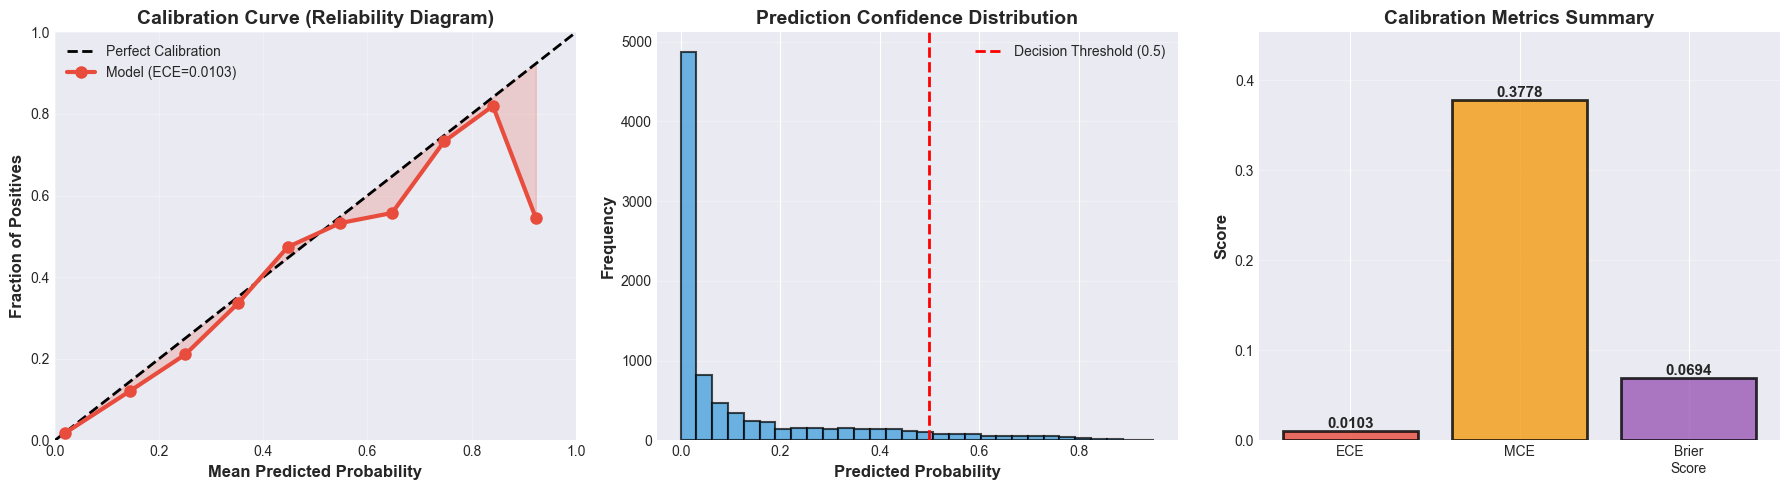

CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0103
Maximum Calibration Error (MCE):  0.3778
Brier Score:                       0.0694

INTERPRETATION:
✓ ECE < 0.05: Excellent calibration
✓ Brier Score < 0.10: Excellent probability estimates


In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss  # Add this import
y_prob_pos = y_prob[:, 1]
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calculate Expected Calibration Error (ECE)
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        prop_in_bin = in_bin.mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    
    return ece

def maximum_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calculate Maximum Calibration Error (MCE)
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    mce = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (y_prob > bin_lower) & (y_prob <= bin_upper)
        
        if in_bin.sum() > 0:
            accuracy_in_bin = y_true[in_bin].mean()
            avg_confidence_in_bin = y_prob[in_bin].mean()
            mce = max(mce, np.abs(avg_confidence_in_bin - accuracy_in_bin))
    
    return mce

def plot_calibration_metrics(y_true, y_prob_pos, n_bins=10):
    """
    Visualize calibration metrics with simple plots
    """
    # Calculate calibration metrics
    ece = expected_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    brier = brier_score_loss(y_true, y_prob_pos)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Reliability Diagram (Calibration Curve)
    ax1 = axes[0]
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob_pos, n_bins=n_bins, strategy='uniform'
    )
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.plot(mean_predicted_value, fraction_of_positives, 
             'o-', color='#e74c3c', linewidth=3, markersize=8,
             label=f'Model (ECE={ece:.4f})')
    ax1.fill_between(mean_predicted_value, fraction_of_positives, 
                      mean_predicted_value, alpha=0.2, color='#e74c3c')
    ax1.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
    ax1.set_title('Calibration Curve (Reliability Diagram)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    # 2. Confidence Histogram
    ax2 = axes[1]
    ax2.hist(y_prob_pos, bins=30, color='#3498db', alpha=0.7, 
             edgecolor='black', linewidth=1.5)
    ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, 
                label='Decision Threshold (0.5)')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Confidence Distribution', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Calibration Metrics Bar Chart
    ax3 = axes[2]
    metrics = {
        'ECE': ece,
        'MCE': mce,
        'Brier\nScore': brier
    }
    colors = ['#e74c3c', '#f39c12', '#9b59b6']
    bars = ax3.bar(metrics.keys(), metrics.values(), 
                   color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax3.set_title('Calibration Metrics Summary', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, max(metrics.values()) * 1.2])
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('calibration_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print metrics
    print("="*60)
    print("CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)")
    print("="*60)
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Maximum Calibration Error (MCE):  {mce:.4f}")
    print(f"Brier Score:                       {brier:.4f}")
    print("="*60)
    
    # Interpretation
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    if ece < 0.05:
        print("✓ ECE < 0.05: Excellent calibration")
    elif ece < 0.10:
        print("⚠ ECE < 0.10: Good calibration")
    else:
        print("✗ ECE ≥ 0.10: Poor calibration - consider calibration methods")
    
    if brier < 0.10:
        print("✓ Brier Score < 0.10: Excellent probability estimates")
    elif brier < 0.20:
        print("⚠ Brier Score < 0.20: Good probability estimates")
    else:
        print("✗ Brier Score ≥ 0.20: Poor probability estimates")
    print("="*60)

# Visualize calibration
plot_calibration_metrics(y_true, y_prob_pos, n_bins=10)

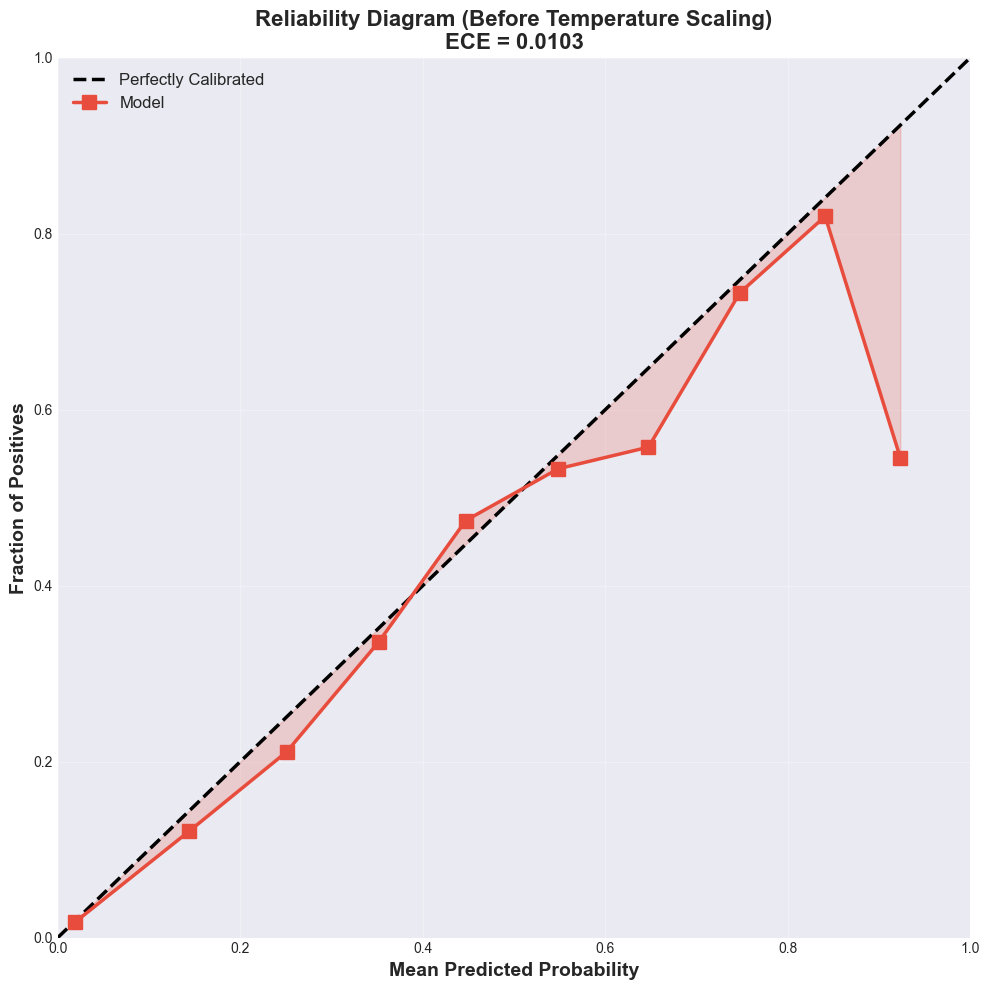

In [43]:
def plot_reliability_diagram(y_true, y_prob, n_bins=10, title='Reliability Diagram'):
    """
    Plot reliability diagram
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Calculate calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy='uniform'
    )
    
    # Plot perfectly calibrated line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=2.5)
    
    # Plot model calibration
    ax.plot(mean_predicted_value, fraction_of_positives, 's-', 
            label='Model', linewidth=2.5, markersize=10, color='#e74c3c')
    
    # Fill gap area
    ax.fill_between(mean_predicted_value, fraction_of_positives, mean_predicted_value,
                     alpha=0.2, color='#e74c3c')
    
    ece_val = expected_calibration_error(y_true, y_prob, n_bins)
    
    ax.set_xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
    ax.set_ylabel('Fraction of Positives', fontsize=14, fontweight='bold')
    ax.set_title(f'{title}\nECE = {ece_val:.4f}', fontsize=16, fontweight='bold')
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

# Plot reliability diagram for uncalibrated model
plot_reliability_diagram(y_true, y_prob_pos, n_bins=10, 
                         title='Reliability Diagram (Before Temperature Scaling)')

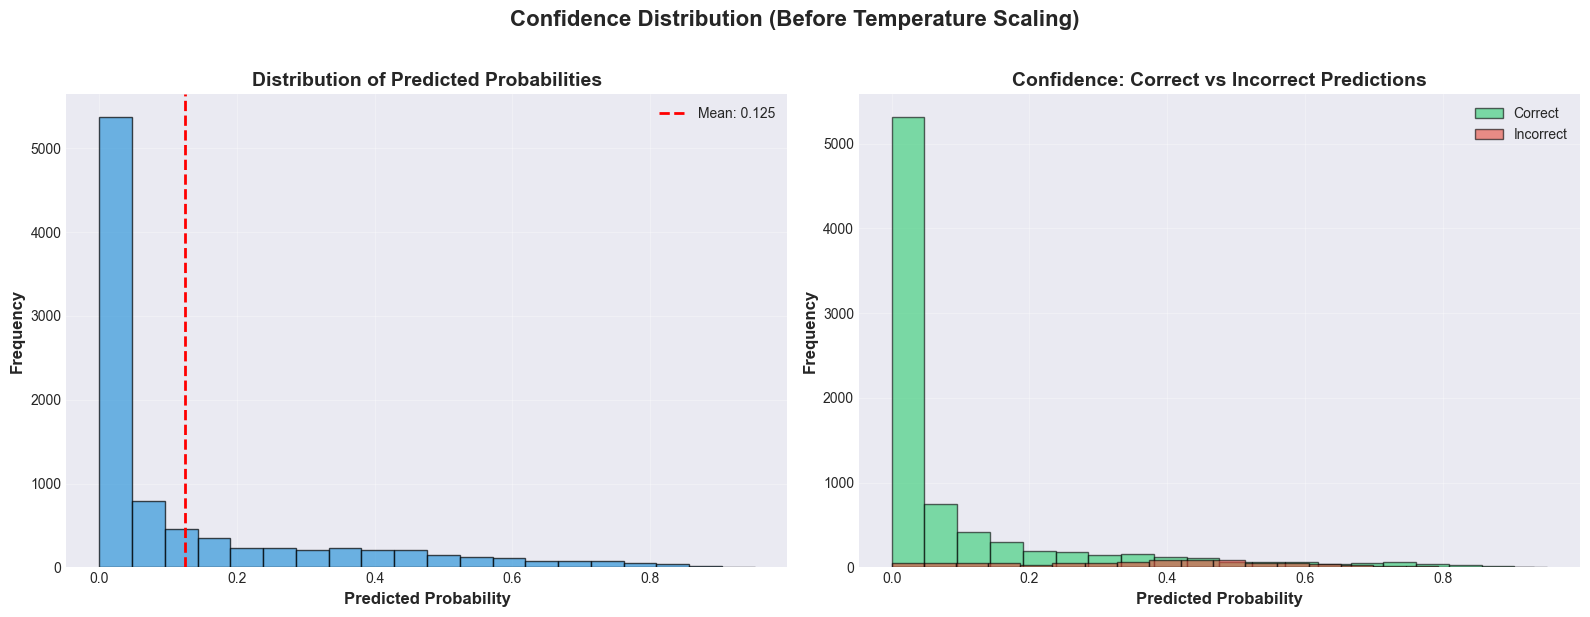

In [44]:
def plot_confidence_histogram(y_true, y_prob, title='Confidence Distribution'):
    """
    Plot histogram of prediction confidences
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram for all predictions
    ax1.hist(y_prob, bins=20, alpha=0.7, edgecolor='black', color='#3498db')
    ax1.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axvline(y_prob.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {y_prob.mean():.3f}')
    ax1.legend(fontsize=10)
    
    # Separate histograms for correct and incorrect predictions
    correct_mask = (y_prob > 0.5) == y_true
    
    ax2.hist(y_prob[correct_mask], bins=20, alpha=0.6, label='Correct', 
             edgecolor='black', color='#2ecc71')
    ax2.hist(y_prob[~correct_mask], bins=20, alpha=0.6, label='Incorrect', 
             edgecolor='black', color='#e74c3c')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Plot confidence histogram
plot_confidence_histogram(y_true, y_prob_pos, 
                          title='Confidence Distribution (Before Temperature Scaling)')

In [45]:
class TemperatureScaling(nn.Module):
    """
    Temperature scaling for model calibration
    """
    def __init__(self):
        super(TemperatureScaling, self).__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    
    def forward(self, logits):
        return logits / self.temperature

def learn_temperature(logits, labels, max_iter=50, lr=0.01):
    """
    Learn optimal temperature parameter using LBFGS
    """
    nll_criterion = nn.CrossEntropyLoss()
    temp_model = TemperatureScaling()
    optimizer = optim.LBFGS([temp_model.temperature], lr=lr, max_iter=max_iter)
    
    logits = torch.FloatTensor(logits)
    labels = torch.LongTensor(labels)
    
    def eval_loss():
        optimizer.zero_grad()
        loss = nll_criterion(temp_model(logits), labels)
        loss.backward()
        return loss
    
    optimizer.step(eval_loss)
    
    temperature = temp_model.temperature.item()
    return temperature

# Get validation logits for temperature scaling
_, _, y_val_true, y_val_logits = evaluate_model(model, val_loader)

# Learn temperature on validation set
print("Learning temperature parameter on validation set...")
temperature = learn_temperature(y_val_logits, y_val_true)
print(f"Learned temperature: {temperature:.4f}")

Learning temperature parameter on validation set...
Learned temperature: 1.1663


In [46]:
# Apply temperature scaling to test set
def apply_temperature_scaling(logits, temperature):
    """
    Apply temperature scaling to logits
    """
    scaled_logits = torch.FloatTensor(logits) / temperature
    probs = torch.softmax(scaled_logits, dim=1)
    return probs.numpy()

# Get calibrated probabilities
y_prob_calibrated = apply_temperature_scaling(y_logits, temperature)
y_prob_calibrated_pos = y_prob_calibrated[:, 1]

# Calculate calibration metrics after temperature scaling
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

print("="*60)
print("CALIBRATION METRICS (AFTER TEMPERATURE SCALING)")
print("="*60)
print(f"Expected Calibration Error (ECE): {ece_after:.4f}")
print(f"Maximum Calibration Error (MCE):  {mce_after:.4f}")
print(f"Brier Score:                       {brier_after:.4f}")
print("="*60)

CALIBRATION METRICS (AFTER TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0224
Maximum Calibration Error (MCE):  0.4104
Brier Score:                       0.0700


In [47]:
# Apply temperature scaling to test set
def apply_temperature_scaling(logits, temperature):
    """
    Apply temperature scaling to logits
    """
    scaled_logits = torch.FloatTensor(logits) / temperature
    probs = torch.softmax(scaled_logits, dim=1)
    return probs.numpy()

# Get calibrated probabilities
y_prob_calibrated = apply_temperature_scaling(y_logits, temperature)
y_prob_calibrated_pos = y_prob_calibrated[:, 1]

# Calculate calibration metrics after temperature scaling
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

print("="*60)
print("CALIBRATION METRICS (AFTER TEMPERATURE SCALING)")
print("="*60)
print(f"Expected Calibration Error (ECE): {ece_after:.4f}")
print(f"Maximum Calibration Error (MCE):  {mce_after:.4f}")
print(f"Brier Score:                       {brier_after:.4f}")
print("="*60)

CALIBRATION METRICS (AFTER TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0224
Maximum Calibration Error (MCE):  0.4104
Brier Score:                       0.0700


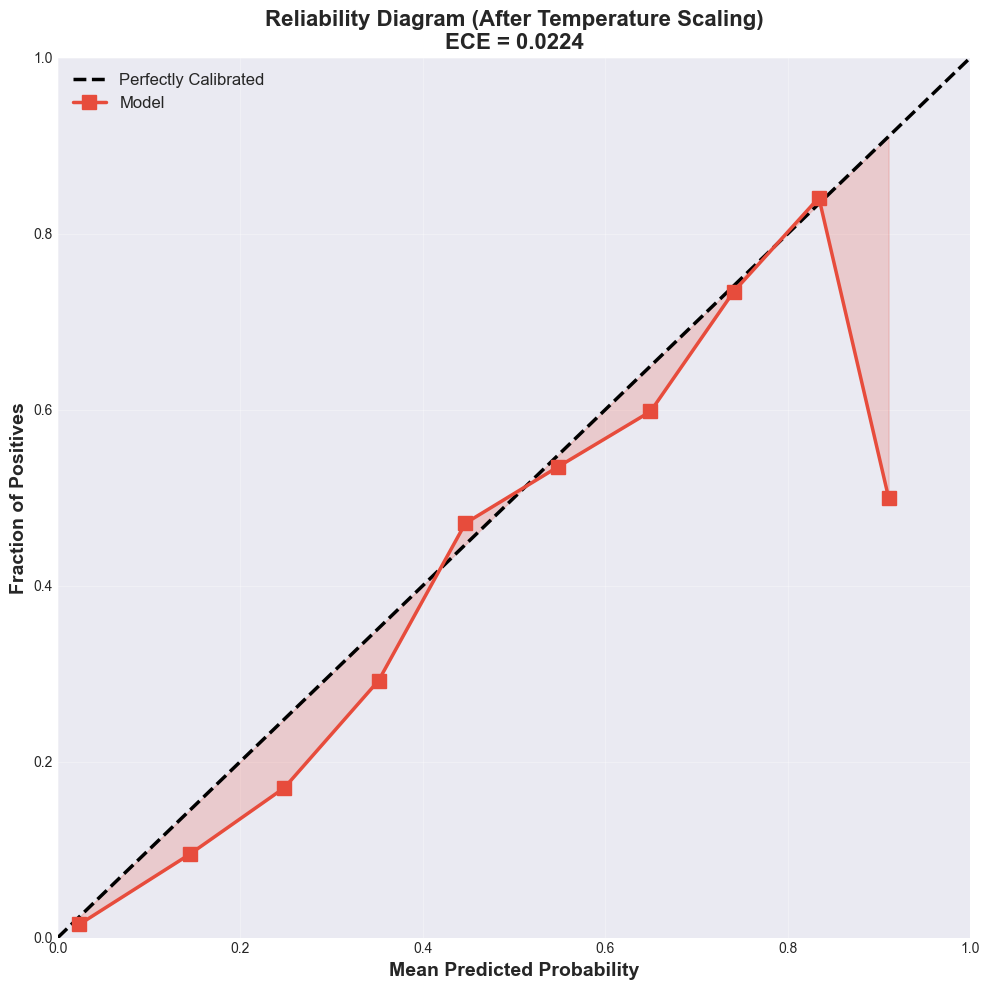

In [48]:
# Reliability diagram after temperature scaling
plot_reliability_diagram(y_true, y_prob_calibrated_pos, n_bins=10,
                         title='Reliability Diagram (After Temperature Scaling)')

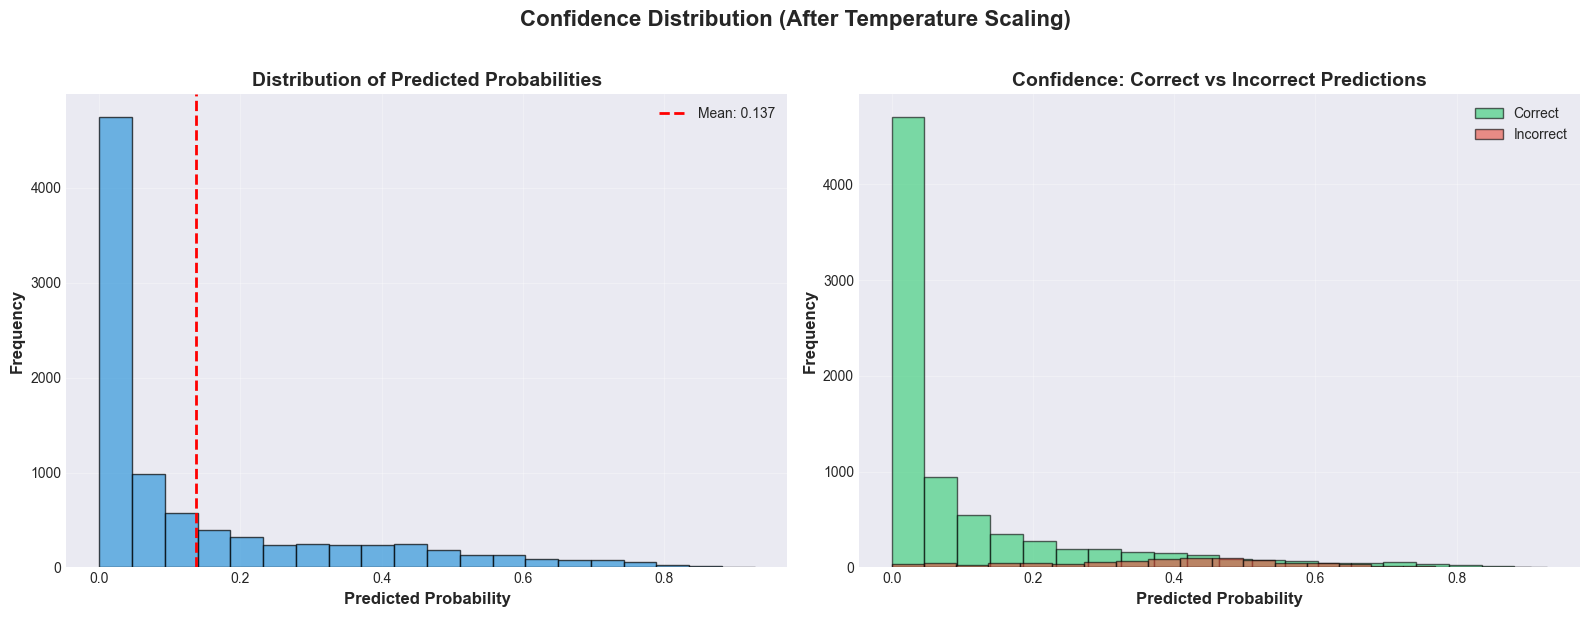

In [49]:
# Confidence histogram after temperature scaling
plot_confidence_histogram(y_true, y_prob_calibrated_pos,
                          title='Confidence Distribution (After Temperature Scaling)')

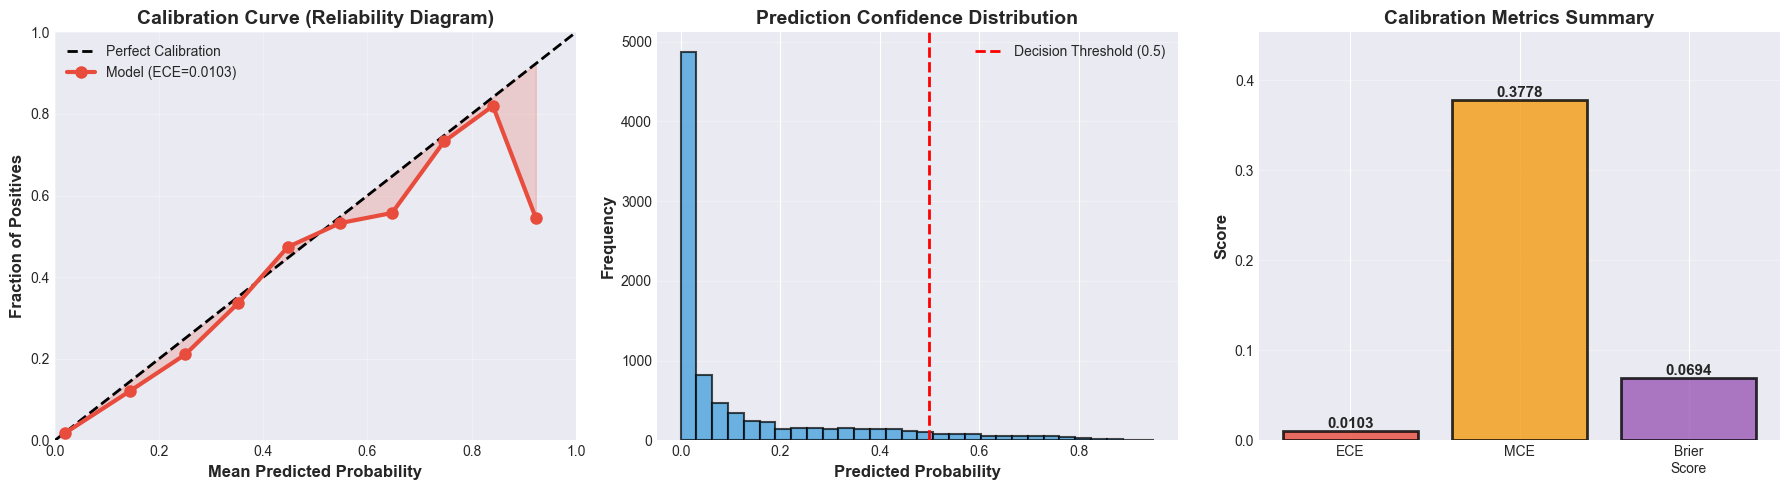

CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)
Expected Calibration Error (ECE): 0.0103
Maximum Calibration Error (MCE):  0.3778
Brier Score:                       0.0694

INTERPRETATION:
✓ ECE < 0.05: Excellent calibration
✓ Brier Score < 0.10: Excellent probability estimates


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve
y_prob_pos = y_prob[:, 1]
def plot_calibration_metrics(y_true, y_prob_pos, n_bins=10):
    """
    Visualize calibration metrics with simple plots
    """
    # Calculate calibration metrics
    ece = expected_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=n_bins)
    brier = brier_score_loss(y_true, y_prob_pos)
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Reliability Diagram (Calibration Curve)
    ax1 = axes[0]
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_true, y_prob_pos, n_bins=n_bins, strategy='uniform'
    )
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    ax1.plot(mean_predicted_value, fraction_of_positives, 
             'o-', color='#e74c3c', linewidth=3, markersize=8,
             label=f'Model (ECE={ece:.4f})')
    ax1.fill_between(mean_predicted_value, fraction_of_positives, 
                      mean_predicted_value, alpha=0.2, color='#e74c3c')
    ax1.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
    ax1.set_title('Calibration Curve (Reliability Diagram)', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    # 2. Confidence Histogram
    ax2 = axes[1]
    ax2.hist(y_prob_pos, bins=30, color='#3498db', alpha=0.7, 
             edgecolor='black', linewidth=1.5)
    ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=2, 
                label='Decision Threshold (0.5)')
    ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax2.set_title('Prediction Confidence Distribution', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Calibration Metrics Bar Chart
    ax3 = axes[2]
    metrics = {
        'ECE': ece,
        'MCE': mce,
        'Brier\nScore': brier
    }
    colors = ['#e74c3c', '#f39c12', '#9b59b6']
    bars = ax3.bar(metrics.keys(), metrics.values(), 
                   color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    
    ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax3.set_title('Calibration Metrics Summary', fontsize=14, fontweight='bold')
    ax3.set_ylim([0, max(metrics.values()) * 1.2])
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('calibration_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print metrics
    print("="*60)
    print("CALIBRATION METRICS (BEFORE TEMPERATURE SCALING)")
    print("="*60)
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Maximum Calibration Error (MCE):  {mce:.4f}")
    print(f"Brier Score:                       {brier:.4f}")
    print("="*60)
    
    # Interpretation
    print("\n" + "="*60)
    print("INTERPRETATION:")
    print("="*60)
    if ece < 0.05:
        print("✓ ECE < 0.05: Excellent calibration")
    elif ece < 0.10:
        print("⚠ ECE < 0.10: Good calibration")
    else:
        print("✗ ECE ≥ 0.10: Poor calibration - consider calibration methods")
    
    if brier < 0.10:
        print("✓ Brier Score < 0.10: Excellent probability estimates")
    elif brier < 0.20:
        print("⚠ Brier Score < 0.20: Good probability estimates")
    else:
        print("✗ Brier Score ≥ 0.20: Poor probability estimates")
    print("="*60)

# Visualize calibration
plot_calibration_metrics(y_true, y_prob_pos, n_bins=10)

In [52]:
# Create comprehensive results table
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss

# Performance metrics
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob[:, 1])

# Calibration metrics (before)
ece = expected_calibration_error(y_true, y_prob_pos, n_bins=10)
mce = maximum_calibration_error(y_true, y_prob_pos, n_bins=10)
brier = brier_score_loss(y_true, y_prob_pos)

# Calibration metrics (after temperature scaling)
ece_after = expected_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
mce_after = maximum_calibration_error(y_true, y_prob_calibrated_pos, n_bins=10)
brier_after = brier_score_loss(y_true, y_prob_calibrated_pos)

# Improvements (safe division)
ece_improvement = ((ece - ece_after) / ece * 100) if ece > 0 else 0.0
brier_improvement = ((brier - brier_after) / brier * 100) if brier > 0 else 0.0

results_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'F1-Score',
        'AUC-ROC',
        'ECE (Before)',
        'ECE (After)',
        'ECE Improvement (%)',
        'Brier Score (Before)',
        'Brier Score (After)',
        'Brier Improvement (%)',
        'Temperature',
        'Architecture',
        'Total Parameters',
        'Training Epochs',
        'Optimizer'
    ],
    'Value': [
        f"{accuracy:.4f}",
        f"{f1:.4f}",
        f"{auc:.4f}",
        f"{ece:.4f}",
        f"{ece_after:.4f}",
        f"{ece_improvement:.1f}%",
        f"{brier:.4f}",
        f"{brier_after:.4f}",
        f"{brier_improvement:.1f}%",
        f"{temperature:.4f}",
        'MLP (128-64-2)',
        f"{sum(p.numel() for p in model.parameters()):,}",
        '30',
        'Adam (lr=0.001)'
    ]
})

print("\n" + "="*60)
print("WINE QUALITY DATASET - COMPREHENSIVE RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)



WINE QUALITY DATASET - COMPREHENSIVE RESULTS
               Metric           Value
             Accuracy          0.8991
             F1-Score          0.4692
              AUC-ROC          0.9047
         ECE (Before)          0.0103
          ECE (After)          0.0224
  ECE Improvement (%)         -118.4%
 Brier Score (Before)          0.0694
  Brier Score (After)          0.0700
Brier Improvement (%)           -0.9%
          Temperature          1.1663
         Architecture  MLP (128-64-2)
     Total Parameters          10,562
      Training Epochs              30
            Optimizer Adam (lr=0.001)
